# (30) Curvature analysis: Lion vs. MassiveLion

device = ```cuda:0```

This time, use a more reasonable Lion model (lower learning rate)

**Motivation**: <br>

## Follow-Up Sharpness Report: MassiveLion vs Larger-Batch / Smaller-LR Lion

### Motivation

The previous comparison was between MassiveLion and a Lion-limit run that had a much larger parameter norm and much worse normalized robustness. The emerging story was:

> Raw Euclidean curvature made MassiveLion look sharper, but scale-aware and function-space metrics showed Lion was actually much more brittle.

Now we compare MassiveLion to a different Lion fit trained with **larger batch size and smaller learning rate**, to test whether Lion’s brittleness was partly a training-regime artifact. The answer appears to be yes: this new Lion fit is dramatically less brittle than the previous Lion fit. However, it also performs worse.

### Baseline Performance

Across the notebook measurements, MassiveLion remains clearly better in ordinary validation performance.

| model | base loss | base acc |
|---|---:|---:|
| MassiveLion | `0.256-0.261` | `93.5%` |
| new Lion | `1.01-1.05` | `88.5-88.9%` |

So the larger-batch / smaller-LR Lion did **not** close the performance gap. It is smoother than the previous Lion, but lower performing.

### 0. Raw Curvature Diagnostics

The standard curvature diagnostics again make MassiveLion look vastly sharper.

| metric | MassiveLion | new Lion | MLion / Lion |
|---|---:|---:|---:|
| probe loss | `0.259` | `1.003` | `0.26x` |
| probe grad norm | `314.0` | `3.84` | `82x` |
| Hessian trace / param | `5.98` | `3.24e-4` | `1.84e4x` |
| lambda max | `6.20e6` | `358` | `1.73e4x` |
| spectral radius | `6.20e6` | `358` | `1.73e4x` |
| random sharpness AUC | `0.848` | `8.33e-4` | `1018x` |
| theta norm | `69.38` | `151.6` | `0.46x` |

Compared to the previous Lion-limit run, the new Lion has a much smaller parameter norm than before (`151.6` vs roughly `768.7`). It is no longer the extreme high-norm saturated solution. Still, raw curvature says MassiveLion is much sharper.

Interpretation: raw Euclidean curvature remains difficult to trust. MassiveLion has much larger probe gradient and Hessian values in parameter coordinates, but these numbers are still sensitive to parameterization, logit confidence, and the local CE geometry. The more meaningful question is whether the function changes under normalized perturbations.

### 1. Filter-Normalized Adversarial CE Sharpness

This metric perturbs each filter in proportion to its own norm and adversarially maximizes CE loss. It asks a scale-aware worst-case robustness question.

| rho | MassiveLion sharpness | new Lion sharpness | new Lion / MLion |
|---:|---:|---:|---:|
| `1e-4` | `1.04e-4` | `2.98e-4` | `2.9x` |
| `3e-4` | `3.06e-4` | `8.93e-4` | `2.9x` |
| `1e-3` | `1.04e-3` | `2.90e-3` | `2.8x` |
| `3e-3` | `3.45e-3` | `8.72e-3` | `2.5x` |
| `1e-2` | `1.61e-2` | `3.00e-2` | `1.9x` |
| `3e-2` | `1.06e-1` | `1.03e-1` | `1.0x` |
| `1e-1` | `1.79` | `0.726` | `0.4x` |
| `3e-1` | `9.74` | `28.27` | `2.9x` |

At small radii, new Lion is still a bit sharper than MassiveLion under adversarial CE, but only by about `2-3x`. This is completely different from the previous Lion, which was tens to hundreds of times sharper at small radii and catastrophically unstable by moderate radii.

Interpretation: larger batch / smaller LR seems to have removed the extreme adversarial CE brittleness of the earlier Lion run. But this did not translate into better accuracy.

### 2. Function-Space Adversarial KL Sensitivity

This metric measures predictive distribution change:

$$
KL(p_\theta || p_{\theta+\delta}) \approx \frac{1}{2}\delta^\top F\delta
$$

So it probes Fisher/information-geometric stiffness of the learned function.

| rho | MassiveLion KL | new Lion KL | new Lion / MLion |
|---:|---:|---:|---:|
| `1e-4` | `2.12e-8` | `7.19e-8` | `3.4x` |
| `3e-4` | `2.80e-8` | `8.51e-8` | `3.0x` |
| `1e-3` | `3.66e-8` | `8.93e-8` | `2.4x` |
| `3e-3` | `1.15e-7` | `1.62e-7` | `1.4x` |
| `1e-2` | `4.89e-6` | `9.74e-7` | `0.2x` |
| `3e-2` | `1.46e-2` | `2.28e-3` | `0.16x` |

This is the biggest qualitative change from the previous comparison. The earlier Lion had enormous adversarial KL values, e.g. `0.053` at `rho=1e-3` and `3.88` at `rho=1e-2`. The new Lion is near numerical floor through `rho=3e-3`, and at larger radii it is actually less KL-sensitive than MassiveLion.

Interpretation: this new Lion fit is no longer functionally brittle in the Fisher/KL sense. The dangerous stiff functional modes seen in the previous Lion run have mostly disappeared.

### 3. Thermal Weight-Noise Susceptibility

Thermal susceptibility injects random filter-normalized noise and measures typical KL/loss response. This is complementary to adversarial perturbations: it asks about basin volume, not worst-case directions.

| rho | MassiveLion mean KL | new Lion mean KL | new Lion / MLion |
|---:|---:|---:|---:|
| `1e-3` | `2.93e-8` | `8.24e-8` | `2.8x` |
| `3e-3` | `3.77e-8` | `1.01e-7` | `2.7x` |
| `1e-2` | `6.44e-8` | `1.61e-7` | `2.5x` |
| `3e-2` | `1.57e-7` | `3.45e-7` | `2.2x` |
| `1e-1` | `9.35e-7` | `1.84e-6` | `2.0x` |

The new Lion has slightly higher thermal susceptibility than MassiveLion, but the absolute values are tiny. Accuracy barely moves.

Interpretation: both models are locally stable to typical random normalized perturbations. New Lion has a slightly more thermally susceptible basin, but not in a way that seems practically catastrophic.

### 4. Fisher/KL Normal-Mode Spectrum

This treats the Fisher/KL Hessian in filter-normalized coordinates as a stiffness matrix. Eigenvalues are normal-mode stiffnesses.

| metric | MassiveLion | new Lion | previous Lion |
|---|---:|---:|---:|
| lambda max | `168.3` | `121.8` | `225088.6` |
| random Rayleigh mean | `1.75e-4` | `3.20e-4` | `1.26e-1` |
| stiff mode ratio | `9.63e5` | `3.81e5` | `1.78e6` |

Top modes:

| rank | MassiveLion eig | new Lion eig |
|---:|---:|---:|
| 1 | `168.3` | `121.8` |
| 2 | `154.8` | `91.5` |
| 3 | `131.3` | `86.6` |
| 4 | `119.3` | `73.6` |
| 5 | `115.8` | `53.3` |

This is the clearest mechanistic contrast with the previous Lion fit. The previous Lion had enormous stiff normal modes. The new Lion does not. Its top Fisher/KL stiffness is actually lower than MassiveLion’s, though its random-direction stiffness is about `1.8x` higher.

Interpretation: larger batch / smaller LR dramatically changed Lion’s local geometry. It removed the huge stiff modes, making the solution much more mechanically tame. However, the resulting function is lower accuracy.

### What Changed Relative To The Previous Report?

The previous Lion-limit fit looked like this:

- much larger parameter norm,
- raw CE curvature artificially tiny,
- enormous normalized adversarial CE sharpness,
- enormous adversarial KL sensitivity,
- enormous Fisher/KL normal-mode stiffness.

The new Lion fit looks like this:

- lower parameter norm than the previous Lion,
- no catastrophic normalized KL instability,
- no enormous Fisher/KL stiff modes,
- only mildly higher thermal susceptibility than MassiveLion,
- but substantially worse accuracy.

So the story changed from:

> Lion is better described as high-norm, saturated, and functionally brittle.

to:

> This larger-batch / smaller-LR Lion is functionally much smoother and more stable, but appears lower performing.

### Physical / Mechanistic Interpretation

The earlier Lion solution looked like a high-norm, saturated configuration with hidden stiff directions. In a mechanics analogy, it had very sharp normal modes: most random kicks did little, but adversarially chosen perturbations found extremely stiff fault lines.

The new Lion fit appears to have cooled or regularized away those fault lines. Its Fisher/KL stiffness spectrum is no longer huge. Its adversarial KL is small. Its thermal response is tiny. Mechanically, it is a much softer and less anisotropic object than the previous Lion solution.

But this geometric improvement did not improve the learned function. Its validation accuracy is lower than both MassiveLion and the previous Lion-like run. That suggests the larger-batch / smaller-LR recipe may have produced a smoother but less useful solution, possibly because it reduced the optimizer’s ability to explore or reach the high-performing basin.

### Conclusion

The converging evidence now says:

**The previous Lion brittleness was not intrinsic to the Lion update alone. Training regime matters a lot. Larger batch size and smaller learning rate can make Lion dramatically more stable under scale-aware and function-space metrics.**

However:

**MassiveLion still wins on the actual task.** It has much better validation accuracy and lower loss while maintaining good scale-aware robustness.

The refined hypothesis is therefore:

> MassiveLion’s advantage is not simply “it finds a flatter solution” or “Lion is always brittle.” Rather, MassiveLion seems to reach a better accuracy/robustness tradeoff: a high-performing function that remains mechanically stable. The new Lion fit is mechanically stable too, but lower quality.


In [1]:
# HIDE CODE


import os, pathlib
from IPython.display import display

# tmp & extras dir
_jb_dir = pathlib.Path(os.environ['HOME'])
_jb_dir /= 'Dropbox/git/jb-progress-2026'
extras_dir = _jb_dir / '_extras'
fig_base_dir = _jb_dir / 'figs'
tmp_dir = _jb_dir / 'tmp'

from gra.utils.plotting import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
## HIDE CODE


from gra.experiments.vision.models import WideResNet, ResNet18, ConvNet, MLP


def _ckpt_arg(ckpt, key, default=None):
    args = ckpt.get("args", {})
    return args.get(key, default) if isinstance(args, dict) else getattr(args, key, default)

def _clean_state_dict(sd):
    return {
        k.removeprefix("_orig_mod."): v
        for k, v in sd.items()
    }

def ckpt_to_vision_model(ckpt, device="cpu"):
    dataset = str(_ckpt_arg(ckpt, "dataset", "CIFAR10"))
    model_name = _ckpt_arg(ckpt, "model", "resnet")
    num_classes = 1000 if "imagenet" in dataset.lower() else 10

    model_cls = {
        "resnet": ResNet18,
        "wrn": WideResNet,
        "convnet": ConvNet,
        "mlp": MLP,
    }[model_name]

    model = model_cls(num_classes=num_classes).to(device)
    model.load_state_dict(_clean_state_dict(ckpt["model"]), strict=True)
    model.eval()
    return model

In [3]:
device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: chewie

## load runs

In [4]:
from gra.experiments.common.checkpointing import resolve_resume_source, load_checkpoint

run_paths = {
    "m_lion": "pal-lab/GRA-CIFAR10/ikft1odq",
    "lion": "pal-lab/GRA-CIFAR10/h9vl6ugr",
}

sources = {k: resolve_resume_source(v) for k, v in run_paths.items()}
ckpts = {
    k: load_checkpoint(src.checkpoint_path, map_location="cpu")
    for k, src in sources.items()
}

m_lion_ckpt = ckpts["m_lion"]
lion_ckpt = ckpts["lion"]

wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/hadi/.netrc.


In [5]:
m_lion_model = ckpt_to_vision_model(m_lion_ckpt)
lion_model = ckpt_to_vision_model(lion_ckpt)

,param_l2_norm
MassiveLion,69.383985
Lion,151.600352


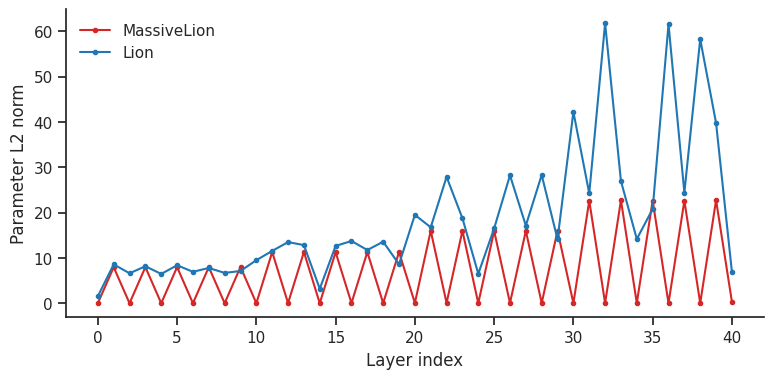

In [6]:
from gra.figures import optimizer_color


def _param_l2(params):
    return sum(p.detach().float().pow(2).sum().item() for p in params) ** 0.5

def model_param_norm(model):
    return _param_l2(model.parameters())

def layer_param_norms(model):
    rows = []
    for layer_idx, (name, module) in enumerate(
        (x for x in model.named_modules() if list(x[1].parameters(recurse=False)))
    ):
        params = list(module.parameters(recurse=False))
        rows.append((layer_idx, name, _param_l2(params)))
    return pd.DataFrame(rows, columns=["layer_idx", "layer", "norm"])

models = {
    "MassiveLion": m_lion_model,
    "Lion": lion_model,
}

overall_norms = pd.Series(
    {name: model_param_norm(model) for name, model in models.items()},
    name="param_l2_norm",
).to_frame()

display(overall_norms)

layer_norms = pd.concat([
    layer_param_norms(model).assign(optim=name)
    for name, model in models.items()
], ignore_index=True)

fig, ax = plt.subplots(figsize=(9, 4))
for name, df in layer_norms.groupby("optim", sort=False):
    ax.plot(
        df["layer_idx"], df["norm"],
        marker="o", ms=3, lw=1.5,
        color=optimizer_color(name),
        label=name,
    )

ax.set(xlabel="Layer index", ylabel="Parameter L2 norm")
ax.legend(frameon=False)
sns.despine()
plt.show()


## (0) curvature metrics (unnormalized)

In [7]:
from types import SimpleNamespace

from gra.utils.dataset import make_dataloader
from gra.experiments.common.optim_factory import configure_optimizer
from gra.experiments.diagnostics.curvature_diagnostics import prepare_curvature_batch
from gra.experiments.diagnostics.diagnostic_logging import compute_final_curvature_outputs

CURVATURE_BATCH_SIZE = 2048
HUTCHINSON_SAMPLES = 32
LANCZOS_STEPS = 48
RANDOM_DIRS = 32

torch.manual_seed(0)

def _args_dict(ckpt):
    args = ckpt.get("args", {})
    return args if isinstance(args, dict) else vars(args)

def _arg(ckpt, *names, default=None):
    args = _args_dict(ckpt)
    for name in names:
        if name in args:
            return args[name]
    return default

def curvature_args(ckpt):
    return SimpleNamespace(
        optim=_arg(ckpt, "optim", "optimizer"),
        lr=_arg(ckpt, "lr", default=1e-3),
        wd=_arg(ckpt, "wd", "weight_decay", default=0.0),
        beta1=_arg(ckpt, "beta1", default=0.9),
        beta2=_arg(ckpt, "beta2", default=0.99),
        beta3=_arg(ckpt, "beta3", default=0.999),
        mass=_arg(ckpt, "mass", default=0.0),
        kappa=_arg(ckpt, "kappa", default=0.0),
        curvature_diagnostics=True,
        curvature_postfit=True,
        curvature_probe_batch_size=CURVATURE_BATCH_SIZE,
        curvature_hutchinson_samples=HUTCHINSON_SAMPLES,
        curvature_lanczos_steps=LANCZOS_STEPS,
        curvature_num_top_eigvecs=8,
        curvature_perturb_radii="1e-4,3e-4,1e-3,3e-3,1e-2",
        curvature_random_dirs=RANDOM_DIRS,
        curvature_slice_grid=0,   # metrics only; set >=3 if you want figs
        curvature_connectivity_ckpt="",
        curvature_ece_bins=15,
    )

def curvature_loss_fn(model, batch):
    x, y = batch
    return F.cross_entropy(model(x), y.long())

In [8]:
dataset = _arg(m_lion_ckpt, "dataset", default="CIFAR10")
_, val_loader = make_dataloader(dataset=dataset, batch_size=CURVATURE_BATCH_SIZE, device="cpu")
curvature_batch = prepare_curvature_batch(next(iter(val_loader)), device, CURVATURE_BATCH_SIZE)

models = {
    "m_lion": m_lion_model.to(device),
    "lion": lion_model.to(device),
}
ckpts = {
    "m_lion": m_lion_ckpt,
    "lion": lion_ckpt,
}

In [9]:
%%time


final_curvature = {}
for name, model in models.items():
    args = curvature_args(ckpts[name])
    optimizer = configure_optimizer(model, args, device)
    optimizer.load_state_dict(ckpts[name].get("optim_state", ckpts[name].get("optimizer")))

    model.zero_grad(set_to_none=True)
    curvature_loss_fn(model, curvature_batch).backward()

    metrics, figs = compute_final_curvature_outputs(
        model=model,
        optimizer=optimizer,
        batch=curvature_batch,
        loss_fn=curvature_loss_fn,
        args=args,
    )
    final_curvature[name] = metrics

Decay params: 11,164,352, No-decay params: 9,610
Optim: MassiveLion (
Parameter Group 0
    betas: (0.7, 0.99)
    lr: 0.001
    mass: 1.0
    weight_decay: 1.0

Parameter Group 1
    betas: (0.7, 0.99)
    lr: 0.001
    mass: 1.0
    weight_decay: 0.0
)
Decay params: 11,164,352, No-decay params: 9,610
Optim: MassiveLion (
Parameter Group 0
    betas: (0.9, 0.99)
    lr: 0.0001
    mass: 0.0
    weight_decay: 1.0

Parameter Group 1
    betas: (0.9, 0.99)
    lr: 0.0001
    mass: 0.0
    weight_decay: 0.0
)
CPU times: user 3min 5s, sys: 54.4 s, total: 4min
Wall time: 4min 1s


In [10]:
final_curvature_df = pd.DataFrame(final_curvature).T
final_curvature_df

,probe_loss,probe_grad_norm,ece,calibration_confidence,calibration_accuracy,calibration_count,hessian_trace,hessian_trace_per_param,hessian_trace_std,lambda_max,...,sharpness_random_max_delta/r_1em04,sharpness_random_mean_delta/r_3em04,sharpness_random_max_delta/r_3em04,sharpness_random_mean_delta/r_1em03,sharpness_random_max_delta/r_1em03,sharpness_random_mean_delta/r_3em03,sharpness_random_max_delta/r_3em03,sharpness_random_mean_delta/r_1em02,sharpness_random_max_delta/r_1em02,sharpness_random_auc
m_lion,0.259231,314.024109,0.021052,0.946975,0.93457,2048.0,6.681416e+07,5.979451,1.849667e+07,6.196698e+06,...,0.001213,0.002165,0.004104,0.012601,0.023840,0.143018,0.227645,2.209678,2.540794,0.848030
lion,1.003400,3.843076,0.093652,0.982812,0.88916,2048.0,3.624813e+03,0.000324,8.086176e+02,3.579559e+02,...,0.000099,0.000073,0.000174,0.000171,0.000464,0.000485,0.001513,0.001657,0.004618,0.000833


## (1) filter-normalized adversarial sharpness

In [7]:
from gra.utils.dataset import make_dataloader

dataset = _ckpt_arg(m_lion_ckpt, "dataset", "CIFAR10")
batch_size = int(_ckpt_arg(m_lion_ckpt, "batch_size", 256))

train_loader, val_loader = make_dataloader(
    dataset=dataset,
    batch_size=batch_size,
    device=device,
)

loader = val_loader

In [8]:
import copy
import math
import torch
import torch.nn.functional as F
from collections import OrderedDict

m_lion_model = m_lion_model.to(device).eval()
lion_model = lion_model.to(device).eval()


def _batch_loss(model, x, y):
    out = model(x)
    if isinstance(out, tuple):
        out = out[0]
    return F.cross_entropy(out, y.long())


def _eval_loss_acc(model, loader, max_batches=20):
    model.eval()
    total_loss = total_correct = total_n = 0
    with torch.no_grad():
        for bi, (x, y) in enumerate(loader):
            if bi >= max_batches:
                break
            x, y = x.to(device), y.to(device)
            logits = model(x)
            if isinstance(logits, tuple):
                logits = logits[0]
            loss = F.cross_entropy(logits, y.long(), reduction="sum")
            total_loss += loss.item()
            total_correct += logits.argmax(1).eq(y).sum().item()
            total_n += y.numel()
    return total_loss / total_n, total_correct / total_n


def _filter_norms(param, eps=1e-12):
    # Per-output-filter norm for conv/linear weights; scalar/bias gets abs value.
    if param.ndim <= 1:
        return param.detach().abs().clamp_min(eps)
    return param.detach().flatten(1).norm(dim=1).clamp_min(eps).view(
        -1, *([1] * (param.ndim - 1))
    )


def _init_filter_normalized_delta(model):
    delta = OrderedDict()
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        d = torch.randn_like(p)
        d = d * (_filter_norms(p) / _filter_norms(d))
        delta[name] = d
    return delta


def _delta_norm(delta, model):
    # Norm in filter-normalized coordinates: || delta / ||filter|| ||_2.
    sq = 0.0
    params = dict(model.named_parameters())
    for name, d in delta.items():
        scale = _filter_norms(params[name])
        sq = sq + ((d / scale) ** 2).sum()
    return sq.sqrt()


def _project_delta_(delta, model, rho):
    norm = _delta_norm(delta, model)
    if norm > rho:
        scale = rho / (norm + 1e-12)
        for d in delta.values():
            d.mul_(scale)


def _add_delta_(model, delta, alpha=1.0):
    with torch.no_grad():
        for name, p in model.named_parameters():
            if name in delta:
                p.add_(delta[name], alpha=alpha)


def filter_normalized_adversarial_sharpness(
    model,
    loader,
    rho=1.0,
    ascent_steps=10,
    ascent_lr=None,
    max_batches=20,
):
    """
    Returns max_{||delta/filter_norm(theta)|| <= rho}
        loss(theta + delta) - loss(theta)

    This is the Li et al. filter-normalized neighborhood, optimized with
    projected gradient ascent, so it is much less sensitive to raw weight scale.
    """
    model = copy.deepcopy(model).to(device).eval()

    base_loss, base_acc = _eval_loss_acc(model, loader, max_batches=max_batches)
    delta = _init_filter_normalized_delta(model)
    _project_delta_(delta, model, rho)

    if ascent_lr is None:
        ascent_lr = rho / max(1, ascent_steps // 2)

    batches = []
    for bi, batch in enumerate(loader):
        if bi >= max_batches:
            break
        x, y = batch
        batches.append((x.to(device), y.to(device)))

    for _ in range(ascent_steps):
        _add_delta_(model, delta, alpha=1.0)

        for p in model.parameters():
            p.grad = None

        loss = 0.0
        n = 0
        for x, y in batches:
            batch_loss = _batch_loss(model, x, y)
            loss = loss + batch_loss * y.numel()
            n += y.numel()
        loss = loss / n
        loss.backward()

        _add_delta_(model, delta, alpha=-1.0)

        with torch.no_grad():
            for name, p in model.named_parameters():
                if name not in delta or p.grad is None:
                    continue
                g = p.grad
                # Gradient ascent in filter-normalized coordinates.
                scale = _filter_norms(p)
                delta[name].add_(g * scale.square(), alpha=ascent_lr)
            _project_delta_(delta, model, rho)

    _add_delta_(model, delta, alpha=1.0)
    sharp_loss, sharp_acc = _eval_loss_acc(model, loader, max_batches=max_batches)
    _add_delta_(model, delta, alpha=-1.0)

    return {
        "base_loss": base_loss,
        "base_acc": base_acc,
        "sharp_loss": sharp_loss,
        "sharp_acc": sharp_acc,
        "sharpness": sharp_loss - base_loss,
        "relative_sharpness": (sharp_loss - base_loss) / (base_loss + 1e-12),
        "rho": rho,
        "ascent_steps": ascent_steps,
        "max_batches": max_batches,
    }

In [9]:
%%time


rhos = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1]

sharpness_sweep = {}
for rho in rhos:
    sharpness_sweep[rho] = {
        name: filter_normalized_adversarial_sharpness(
            model,
            loader,
            rho=rho,
            ascent_steps=10,
            max_batches=20,
        )
        for name, model in {
            "m_lion": m_lion_model,
            "lion": lion_model,
        }.items()
    }

for rho, res in sharpness_sweep.items():
    print(f"\nrho={rho:g}")
    for name, r in res.items():
        print(
            name,
            "base_loss", r["base_loss"],
            "sharp_loss", r["sharp_loss"],
            "sharpness", r["sharpness"],
            "base_acc", r["base_acc"],
            "sharp_acc", r["sharp_acc"],
        )


rho=0.0001

m_lion base_loss 0.2558911100029945 sharp_loss 0.25599542409181597 sharpness 0.00010431408882144444 base_acc 
0.9349609375 sharp_acc 0.93515625

lion base_loss 1.0106324136257172 sharp_loss 1.0109299838542938 sharpness 0.00029757022857657134 base_acc 
0.888671875 sharp_acc 0.888671875

rho=0.0003

m_lion base_loss 0.2558911100029945 sharp_loss 0.25619745776057246 sharpness 0.0003063477575779294 base_acc 
0.9349609375 sharp_acc 0.9349609375

...

lion base_loss 1.0106324136257172 sharp_loss 1.736145794391632 sharpness 0.7255133807659149 base_acc 0.888671875 
sharp_acc 0.85

rho=0.3

m_lion base_loss 0.2558911100029945 sharp_loss 9.99895691871643 sharpness 9.743065808713435 base_acc 0.9349609375 
sharp_acc 0.098828125

lion base_loss 1.0106324136257172 sharp_loss 29.27585334777832 sharpness 28.2652209341526 base_acc 0.888671875 
sharp_acc 0.34921875

CPU times: user 54.3 s, sys: 1min 1s, total: 1min 55s
Wall time: 1min 56s


## (2) function-space KL sensitivity

In [7]:
from gra.utils.dataset import make_dataloader

dataset = _ckpt_arg(m_lion_ckpt, "dataset", "CIFAR10")
batch_size = int(_ckpt_arg(m_lion_ckpt, "batch_size", 256))

train_loader, val_loader = make_dataloader(
    dataset=dataset,
    batch_size=batch_size,
    device=device,
)

loader = val_loader

In [8]:
import copy
import torch
import torch.nn.functional as F
from collections import OrderedDict


def _logits(model, x):
    out = model(x)
    return out[0] if isinstance(out, tuple) else out


def _filter_norms(param, eps=1e-12):
    if param.ndim <= 1:
        return param.detach().abs().clamp_min(eps)
    return param.detach().flatten(1).norm(dim=1).clamp_min(eps).view(
        -1, *([1] * (param.ndim - 1))
    )


def _init_delta(model):
    delta = OrderedDict()
    for name, p in model.named_parameters():
        if p.requires_grad:
            d = torch.randn_like(p)
            d = d * (_filter_norms(p) / _filter_norms(d))
            delta[name] = d
    return delta


def _delta_norm(delta, model):
    sq = 0.0
    params = dict(model.named_parameters())
    for name, d in delta.items():
        sq = sq + ((d / _filter_norms(params[name])) ** 2).sum()
    return sq.sqrt()


def _project_delta_(delta, model, rho):
    n = _delta_norm(delta, model)
    if n > rho:
        s = rho / (n + 1e-12)
        for d in delta.values():
            d.mul_(s)


def _add_delta_(model, delta, alpha=1.0):
    with torch.no_grad():
        for name, p in model.named_parameters():
            if name in delta:
                p.add_(delta[name], alpha=alpha)


@torch.no_grad()
def _base_probs(model, batches):
    probs = []
    losses = []
    accs = []
    n_total = 0

    for x, y in batches:
        z = _logits(model, x)
        p = z.softmax(dim=1)
        probs.append(p.detach())

        losses.append(F.cross_entropy(z, y.long(), reduction="sum").item())
        accs.append(z.argmax(1).eq(y).sum().item())
        n_total += y.numel()

    return {
        "probs": probs,
        "loss": sum(losses) / n_total,
        "acc": sum(accs) / n_total,
    }


def _mean_kl_to_base(model, batches, base_probs):
    total_kl = 0.0
    total_n = 0

    for (x, y), p0 in zip(batches, base_probs):
        z = _logits(model, x)
        logp = F.log_softmax(z, dim=1)
        kl = (p0 * (p0.clamp_min(1e-12).log() - logp)).sum(dim=1)
        total_kl = total_kl + kl.sum()
        total_n += x.shape[0]

    return total_kl / total_n


@torch.no_grad()
def _eval_after_delta(model, batches, base_probs):
    total_kl = 0.0
    total_loss = 0.0
    total_correct = 0
    total_n = 0

    for (x, y), p0 in zip(batches, base_probs):
        z = _logits(model, x)
        logp = F.log_softmax(z, dim=1)
        kl = (p0 * (p0.clamp_min(1e-12).log() - logp)).sum(dim=1)

        total_kl += kl.sum().item()
        total_loss += F.cross_entropy(z, y.long(), reduction="sum").item()
        total_correct += z.argmax(1).eq(y).sum().item()
        total_n += y.numel()

    return {
        "kl": total_kl / total_n,
        "loss": total_loss / total_n,
        "acc": total_correct / total_n,
    }


def filter_normalized_adversarial_kl(
    model,
    loader,
    rho=1e-3,
    ascent_steps=10,
    ascent_lr=None,
    max_batches=20,
):
    model = copy.deepcopy(model).to(device).eval()

    batches = []
    for bi, (x, y) in enumerate(loader):
        if bi >= max_batches:
            break
        batches.append((x.to(device), y.to(device)))

    base = _base_probs(model, batches)
    delta = _init_delta(model)
    _project_delta_(delta, model, rho)

    if ascent_lr is None:
        ascent_lr = rho / max(1, ascent_steps // 2)

    for _ in range(ascent_steps):
        _add_delta_(model, delta, alpha=1.0)

        for p in model.parameters():
            p.grad = None

        kl = _mean_kl_to_base(model, batches, base["probs"])
        kl.backward()

        _add_delta_(model, delta, alpha=-1.0)

        with torch.no_grad():
            for name, p in model.named_parameters():
                if name not in delta or p.grad is None:
                    continue
                scale = _filter_norms(p)
                delta[name].add_(p.grad * scale.square(), alpha=ascent_lr)
            _project_delta_(delta, model, rho)

    _add_delta_(model, delta, alpha=1.0)
    pert = _eval_after_delta(model, batches, base["probs"])
    _add_delta_(model, delta, alpha=-1.0)

    return {
        "base_loss": base["loss"],
        "base_acc": base["acc"],
        "pert_loss": pert["loss"],
        "pert_acc": pert["acc"],
        "kl": pert["kl"],
        "rho": rho,
        "ascent_steps": ascent_steps,
        "max_batches": max_batches,
    }

In [9]:
%%time


rhos = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2]

kl_sweep = {}
for rho in rhos:
    kl_sweep[rho] = {
        name: filter_normalized_adversarial_kl(
            model,
            loader,
            rho=rho,
            ascent_steps=10,
            max_batches=20,
        )
        for name, model in {
            "m_lion": m_lion_model,
            "lion": lion_model,
        }.items()
    }

for rho, res in kl_sweep.items():
    print(f"\nrho={rho:g}")
    for name, r in res.items():
        print(
            name,
            "KL", r["kl"],
            "base_acc", r["base_acc"],
            "pert_acc", r["pert_acc"],
            "base_loss", r["base_loss"],
            "pert_loss", r["pert_loss"],
        )


rho=0.0001

m_lion KL 2.1198763811014486e-08 base_acc 0.9349609375 pert_acc 0.9349609375 base_loss 0.2558911100029945 pert_loss
0.2558875821530819

lion KL 7.186628963040675e-08 base_acc 0.888671875 pert_acc 0.888671875 base_loss 1.0106324136257172 pert_loss 
1.0106468439102172

rho=0.0003

m_lion KL 2.800832010763088e-08 base_acc 0.9349609375 pert_acc 0.9349609375 base_loss 0.2558911100029945 pert_loss 
0.255890604108572

...

lion KL 9.737463130932156e-07 base_acc 0.888671875 pert_acc 0.888671875 base_loss 1.0106324136257172 pert_loss 
1.0107801854610443

rho=0.03

m_lion KL 0.014590935246087611 base_acc 0.9349609375 pert_acc 0.9341796875 base_loss 0.2558911100029945 pert_loss 
0.26644428446888924

lion KL 0.0022844096587505192 base_acc 0.888671875 pert_acc 0.888671875 base_loss 1.0106324136257172 pert_loss 
1.0044954895973206

CPU times: user 45.8 s, sys: 45.6 s, total: 1min 31s
Wall time: 1min 27s


## (3) thermal weight-noise susceptibility

In [10]:
from gra.utils.dataset import make_dataloader

dataset = _ckpt_arg(m_lion_ckpt, "dataset", "CIFAR10")
batch_size = int(_ckpt_arg(m_lion_ckpt, "batch_size", 256))

train_loader, val_loader = make_dataloader(
    dataset=dataset,
    batch_size=batch_size,
    device=device,
)

loader = val_loader

In [11]:
import copy
import torch
import torch.nn.functional as F
from collections import OrderedDict


def _logits(model, x):
    z = model(x)
    return z[0] if isinstance(z, tuple) else z


def _filter_norms(param, eps=1e-12):
    if param.ndim <= 1:
        return param.detach().abs().clamp_min(eps)
    return param.detach().flatten(1).norm(dim=1).clamp_min(eps).view(
        -1, *([1] * (param.ndim - 1))
    )


def _random_filter_normalized_delta(model, rho):
    delta = OrderedDict()
    sq = 0.0

    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        scale = _filter_norms(p)
        u = torch.randn_like(p)
        d = u * scale
        delta[name] = d
        sq = sq + ((d / scale) ** 2).sum()

    norm = sq.sqrt()
    for d in delta.values():
        d.mul_(rho / (norm + 1e-12))

    return delta


def _add_delta_(model, delta, alpha=1.0):
    with torch.no_grad():
        for name, p in model.named_parameters():
            if name in delta:
                p.add_(delta[name], alpha=alpha)


@torch.no_grad()
def _base_state(model, batches):
    probs = []
    total_loss = 0.0
    total_correct = 0
    total_n = 0

    for x, y in batches:
        y = y.long()
        z = _logits(model, x)
        p = z.softmax(dim=1)
        probs.append(p.detach())

        total_loss += F.cross_entropy(z, y.long(), reduction="sum").item()
        total_correct += z.argmax(1).eq(y).sum().item()
        total_n += y.numel()

    return {
        "probs": probs,
        "loss": total_loss / total_n,
        "acc": total_correct / total_n,
    }


@torch.no_grad()
def _eval_thermal_sample(model, batches, base_probs):
    total_kl = 0.0
    total_loss = 0.0
    total_correct = 0
    total_n = 0

    for (x, y), p0 in zip(batches, base_probs):
        y = y.long()
        z = _logits(model, x)
        logp = F.log_softmax(z, dim=1)

        kl = (p0 * (p0.clamp_min(1e-12).log() - logp)).sum(dim=1)
        total_kl += kl.sum().item()
        total_loss += F.cross_entropy(z, y.long(), reduction="sum").item()
        total_correct += z.argmax(1).eq(y).sum().item()
        total_n += y.numel()

    return {
        "kl": total_kl / total_n,
        "loss": total_loss / total_n,
        "acc": total_correct / total_n,
    }


def filter_normalized_thermal_susceptibility(
    model,
    loader,
    rho=1e-2,
    samples=20,
    max_batches=20,
):
    model = copy.deepcopy(model).to(device).eval()

    batches = []
    for bi, (x, y) in enumerate(loader):
        if bi >= max_batches:
            break
        batches.append((x.to(device), y.to(device)))

    base = _base_state(model, batches)
    vals = []

    for _ in range(samples):
        delta = _random_filter_normalized_delta(model, rho)
        _add_delta_(model, delta, alpha=1.0)
        vals.append(_eval_thermal_sample(model, batches, base["probs"]))
        _add_delta_(model, delta, alpha=-1.0)

    kl = torch.tensor([v["kl"] for v in vals])
    loss = torch.tensor([v["loss"] for v in vals])
    acc = torch.tensor([v["acc"] for v in vals])

    return {
        "base_loss": base["loss"],
        "base_acc": base["acc"],
        "mean_kl": kl.mean().item(),
        "std_kl": kl.std(unbiased=False).item(),
        "p95_kl": kl.quantile(0.95).item(),
        "mean_loss": loss.mean().item(),
        "mean_loss_increase": (loss.mean().item() - base["loss"]),
        "p95_loss_increase": (loss.quantile(0.95).item() - base["loss"]),
        "mean_acc": acc.mean().item(),
        "worst_acc": acc.min().item(),
        "rho": rho,
        "samples": samples,
        "max_batches": max_batches,
    }

In [12]:
%%time


rhos = [1e-3, 3e-3, 1e-2, 3e-2, 1e-1]

thermal_sweep = {}
for rho in rhos:
    thermal_sweep[rho] = {
        name: filter_normalized_thermal_susceptibility(
            model,
            loader,
            rho=rho,
            samples=30,
            max_batches=20,
        )
        for name, model in {
            "m_lion": m_lion_model,
            "lion": lion_model,
        }.items()
    }

for rho, res in thermal_sweep.items():
    print(f"\nrho={rho:g}")
    for name, r in res.items():
        print(
            name,
            "mean_KL", r["mean_kl"],
            "p95_KL", r["p95_kl"],
            "mean_loss_inc", r["mean_loss_increase"],
            "p95_loss_inc", r["p95_loss_increase"],
            "base_acc", r["base_acc"],
            "mean_acc", r["mean_acc"],
            "worst_acc", r["worst_acc"],
        )


rho=0.001

m_lion mean_KL 2.9300640136398215e-08 p95_KL 3.2380143011323526e-08 mean_loss_inc -1.008808612812384e-06 
p95_loss_inc 4.981458187114374e-06 base_acc 0.9349609375 mean_acc 0.9349673986434937 worst_acc 0.9349609613418579

lion mean_KL 8.239485538297231e-08 p95_KL 9.161360736698043e-08 mean_loss_inc 1.0949373245194849e-05 p95_loss_inc 
2.811551094050735e-05 base_acc 0.888671875 mean_acc 0.888671875 worst_acc 0.888671875

rho=0.003

m_lion mean_KL 3.767386047570653e-08 p95_KL 4.2279765466446406e-08 mean_loss_inc -1.4260411262401185e-06 
p95_loss_inc 3.282725811015741e-06 base_acc 0.9349609375 mean_acc 0.934973955154419 worst_acc 0.9349609613418579

...

lion mean_KL 3.4501888990234875e-07 p95_KL 3.880796555222332e-07 mean_loss_inc 2.2274255752519068e-05 p95_loss_inc 
7.246136665339797e-05 base_acc 0.888671875 mean_acc 0.888671875 worst_acc 0.888671875

rho=0.1

m_lion mean_KL 9.353023529001803e-07 p95_KL 1.387896077176265e-06 mean_loss_inc 4.474818706523553e-06 p95_loss_inc 
5.3171813488017694e-05 base_acc 0.9349609375 mean_acc 0.9350324869155884 worst_acc 0.934765636920929

lion mean_KL 1.8406929029879393e-06 p95_KL 2.1002983885409776e-06 mean_loss_inc 3.09765338897261e-05 p95_loss_inc 
0.0002217113971709761 base_acc 0.888671875 mean_acc 0.888684868812561 worst_acc 0.888671875

CPU times: user 1min 8s, sys: 84.6 ms, total: 1min 8s
Wall time: 1min 4s


## (4) normal-mode spectrum of the filter-normalized Fisher/KL stiffness matrix

In [7]:
from gra.utils.dataset import make_dataloader

dataset = _ckpt_arg(m_lion_ckpt, "dataset", "CIFAR10")
batch_size = int(_ckpt_arg(m_lion_ckpt, "batch_size", 256))

train_loader, val_loader = make_dataloader(
    dataset=dataset,
    batch_size=batch_size,
    device=device,
)

loader = val_loader

In [8]:
import copy
import torch
import torch.nn.functional as F


def _logits(model, x):
    z = model(x)
    return z[0] if isinstance(z, tuple) else z


def _filter_norms(param, eps=1e-12):
    if param.ndim <= 1:
        return param.detach().abs().clamp_min(eps)
    return param.detach().flatten(1).norm(dim=1).clamp_min(eps).view(
        -1, *([1] * (param.ndim - 1))
    )


def _flatten(tensors):
    return torch.cat([t.reshape(-1) for t in tensors])


def _unflatten_like(flat, params):
    out = []
    i = 0
    for p in params:
        n = p.numel()
        out.append(flat[i:i+n].view_as(p))
        i += n
    return out


def _unit(v, eps=1e-12):
    return v / (v.norm() + eps)


@torch.no_grad()
def _collect_batches_and_base(model, loader, max_batches):
    batches = []
    base_probs = []
    total_loss = 0.0
    total_correct = 0
    total_n = 0

    for bi, (x, y) in enumerate(loader):
        if bi >= max_batches:
            break
        x = x.to(device)
        y = y.to(device).long()
        z = _logits(model, x)
        p = z.softmax(dim=1).detach()

        batches.append((x, y))
        base_probs.append(p)

        total_loss += F.cross_entropy(z, y.long(), reduction="sum").item()
        total_correct += z.argmax(1).eq(y).sum().item()
        total_n += y.numel()

    return {
        "batches": batches,
        "base_probs": base_probs,
        "base_loss": total_loss / total_n,
        "base_acc": total_correct / total_n,
        "n_examples": total_n,
    }


def _mean_kl_graph(model, batches, base_probs):
    total = 0.0
    total_n = 0

    for (x, y), p0 in zip(batches, base_probs):
        z = _logits(model, x)
        logp = F.log_softmax(z, dim=1)
        kl = (p0 * (p0.clamp_min(1e-12).log() - logp)).sum(dim=1)
        total = total + kl.sum()
        total_n += x.shape[0]

    return total / total_n


def filter_normalized_fisher_normal_modes(
    model,
    loader,
    max_batches=10,
    lanczos_steps=12,
    random_probes=8,
):
    """
    Estimates spectrum of S F S, where F is the predictive Fisher/KL Hessian
    and S maps normalized filter coordinates to real parameter coordinates.

    Eigenvalues are functional stiffness constants in filter-normalized
    parameter coordinates.
    """
    model = copy.deepcopy(model).to(device).eval()
    state = _collect_batches_and_base(model, loader, max_batches=max_batches)

    params = [p for p in model.parameters() if p.requires_grad]
    scales = [_filter_norms(p).detach() for p in params]
    n_dim = sum(p.numel() for p in params)

    def matvec(q_flat):
        q_parts = _unflatten_like(q_flat.to(device), params)
        real_vec = [q * s for q, s in zip(q_parts, scales)]

        for p in params:
            p.grad = None

        kl = _mean_kl_graph(model, state["batches"], state["base_probs"])
        grads = torch.autograd.grad(
            kl,
            params,
            create_graph=True,
            retain_graph=True,
            allow_unused=True,
        )
        grads = [
            torch.zeros_like(p) if g is None else g
            for g, p in zip(grads, params)
        ]

        dot = sum((g * v).sum() for g, v in zip(grads, real_vec))
        hv = torch.autograd.grad(
            dot,
            params,
            retain_graph=False,
            allow_unused=True,
        )
        hv = [
            torch.zeros_like(p) if h is None else h
            for h, p in zip(hv, params)
        ]

        # Return S F S q, i.e. stiffness in normalized coordinates.
        return _flatten([h * s for h, s in zip(hv, scales)]).detach()

    # Random Rayleigh probes estimate typical stiffness = trace(F_norm) / dim.
    rayleigh = []
    for _ in range(random_probes):
        q = _unit(torch.randn(n_dim, device=device))
        hq = matvec(q)
        rayleigh.append(torch.dot(q, hq).item())

    # Lanczos for top normal modes.
    q = _unit(torch.randn(n_dim, device=device))
    q_prev = torch.zeros_like(q)
    Q = []
    alphas = []
    betas = []
    beta = 0.0

    for k in range(lanczos_steps):
        w = matvec(q)
        if k > 0:
            w = w - beta * q_prev

        alpha = torch.dot(q, w)
        w = w - alpha * q

        # Full reorthogonalization, cheap relative to HVP cost.
        for qi in Q:
            w = w - torch.dot(qi, w) * qi

        beta_next = w.norm()
        Q.append(q)
        alphas.append(alpha.item())

        if beta_next.item() < 1e-10:
            break

        if k < lanczos_steps - 1:
            betas.append(beta_next.item())
            q_prev = q
            q = w / beta_next
            beta = beta_next

    m = len(alphas)
    T = torch.zeros(m, m, device=device)
    for i, a in enumerate(alphas):
        T[i, i] = a
    for i, b in enumerate(betas[:m-1]):
        T[i, i+1] = b
        T[i+1, i] = b

    eigs = torch.linalg.eigvalsh(T).detach().cpu()
    eigs_sorted = eigs.sort(descending=True).values

    random_mean = float(torch.tensor(rayleigh).mean().item())
    random_std = float(torch.tensor(rayleigh).std(unbiased=False).item())
    lambda_max = float(eigs_sorted[0].item())

    return {
        "base_loss": state["base_loss"],
        "base_acc": state["base_acc"],
        "n_examples": state["n_examples"],
        "n_params": n_dim,
        "lambda_max": lambda_max,
        "top_eigs": eigs_sorted[: min(8, len(eigs_sorted))].tolist(),
        "random_rayleigh_mean": random_mean,
        "random_rayleigh_std": random_std,
        "stiff_mode_ratio": lambda_max / (random_mean + 1e-30),
        "lanczos_steps": lanczos_steps,
        "random_probes": random_probes,
        "max_batches": max_batches,
    }


In [9]:
%%time


normal_modes = {
    name: filter_normalized_fisher_normal_modes(
        model,
        loader,
        max_batches=10,
        lanczos_steps=12,
        random_probes=8,
    )
    for name, model in {
        "m_lion": m_lion_model,
        "lion": lion_model,
    }.items()
}

normal_modes

CPU times: user 26.6 s, sys: 33.3 s, total: 59.9 s
Wall time: 1min


{'m_lion': {'base_loss': 0.2614572897553444,
  'base_acc': 0.934765625,
  'n_examples': 2560,
  'n_params': 11173962,
  'lambda_max': 168.32275390625,
  'top_eigs': [168.32275390625,
   154.75433349609375,
   131.2659454345703,
   119.34417724609375,
   115.82569885253906,
   80.15618896484375,
   72.29865264892578,
   52.921504974365234],
  'random_rayleigh_mean': 0.00017474628111813217,
  'random_rayleigh_std': 4.707178959506564e-05,
  'stiff_mode_ratio': 963240.8359664048,
  'lanczos_steps': 12,
  'random_probes': 8,
  'max_batches': 10},
 'lion': {'base_loss': 1.0463807344436646,
  'base_acc': 0.884765625,
  'n_examples': 2560,
  'n_params': 11173962,
  'lambda_max': 121.75535583496094,
  'top_eigs': [121.75535583496094,
   91.46623229980469,
   86.5597915649414,
   73.62808227539062,
   53.25645065307617,
   42.722660064697266,
   31.29312515258789,
   23.05487632751465],
  'random_rayleigh_mean': 0.00031977175967767835,
  'random_rayleigh_std': 2.7835938453790732e-05,
  'stiff_mo